In [ ]:
| Day       | Topic                   | Task                                     |
| --------- | ----------------------- | ---------------------------------------- |
| **Day 1** | Data Loading & Summary  | `.read_csv()`, `.head()`, `.info()`      |
| **Day 2** | Filtering & Sorting     | `df[df['col'] == val]`, `.sort_values()` |
| **Day 3** | GroupBy & Aggregation   | `.groupby()`, `.agg()`                   |
| **Day 4** | Nulls & Column Creation | `.isnull()`, `df['new'] = ...`           |
| **Day 5** | Merging & Joining       | `pd.merge()`, `.join()`                  |
| **Day 6** | Time-based Analysis     | `.dt`, `.resample()`                     |
| **Day 7** | Mini Project            | COVID or Sales Analysis Summary          |


In [1]:
import pandas as pd

In [2]:
pwd

'C:\\Users\\Mayur\\Mayur_pandas_practice'

In [4]:
cd C:\Users\Mayur\Downloads

C:\Users\Mayur\Downloads


In [18]:
df = pd.read_csv("Sales_Data_Pandas_Practice.csv")

In [19]:
df

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit
0,Sub-Saharan Africa,South Africa,Fruits,Offline,High,1/1/2020,123456789,1000,9.33,6.92,9330,6920,2410
1,Middle East and North Africa,Egypt,Clothes,Online,Medium,3/15/2020,234567890,1500,45.00,30.00,67500,45000,22500
2,Asia,India,Beverages,Online,Low,6/10/2020,345678901,500,2.50,1.50,1250,750,500
3,Europe,Germany,Office Supplies,Offline,Critical,8/5/2020,456789012,700,651.00,524.00,455700,366800,88900
4,Australia and Oceania,Australia,Cosmetics,Online,High,11/20/2020,567890123,1300,437.20,263.30,568360,342290,226070


In [20]:
df.head()

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit
0,Sub-Saharan Africa,South Africa,Fruits,Offline,High,1/1/2020,123456789,1000,9.33,6.92,9330,6920,2410
1,Middle East and North Africa,Egypt,Clothes,Online,Medium,3/15/2020,234567890,1500,45.00,30.00,67500,45000,22500
2,Asia,India,Beverages,Online,Low,6/10/2020,345678901,500,2.50,1.50,1250,750,500
3,Europe,Germany,Office Supplies,Offline,Critical,8/5/2020,456789012,700,651.00,524.00,455700,366800,88900
4,Australia and Oceania,Australia,Cosmetics,Online,High,11/20/2020,567890123,1300,437.20,263.30,568360,342290,226070


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          5 non-null      object 
 1   Country         5 non-null      object 
 2   Item_Type       5 non-null      object 
 3   Sales_Channel   5 non-null      object 
 4   Order_Priority  5 non-null      object 
 5   Order_Date      5 non-null      object 
 6   Order_ID        5 non-null      int64  
 7   Units_Sold      5 non-null      int64  
 8   Unit_Price      5 non-null      float64
 9   Unit_Cost       5 non-null      float64
 10  Total_Revenue   5 non-null      int64  
 11  Total_Cost      5 non-null      int64  
 12  Total_Profit    5 non-null      int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 652.0+ bytes


In [22]:
df.shape

(5, 13)

In [23]:
df.describe

<bound method NDFrame.describe of                          Region       Country        Item_Type Sales_Channel  \
0            Sub-Saharan Africa  South Africa           Fruits       Offline   
1  Middle East and North Africa         Egypt          Clothes        Online   
2                          Asia         India        Beverages        Online   
3                        Europe       Germany  Office Supplies       Offline   
4         Australia and Oceania     Australia        Cosmetics        Online   

  Order_Priority  Order_Date   Order_ID  Units_Sold  Unit_Price  Unit_Cost  \
0           High    1/1/2020  123456789        1000        9.33       6.92   
1         Medium   3/15/2020  234567890        1500       45.00      30.00   
2            Low   6/10/2020  345678901         500        2.50       1.50   
3       Critical    8/5/2020  456789012         700      651.00     524.00   
4           High  11/20/2020  567890123        1300      437.20     263.30   

   Total_Revenue

# Unique values

In [25]:
df["Item_Type"].unique()

array(['Fruits', 'Clothes', 'Beverages', 'Office Supplies', 'Cosmetics'],
      dtype=object)

In [26]:
df["Region"].unique()

array(['Sub-Saharan Africa', 'Middle East and North Africa', 'Asia',
       'Europe', 'Australia and Oceania'], dtype=object)

In [32]:
df["Order_Priority"].unique()

array(['High', 'Medium', 'Low', 'Critical'], dtype=object)

# GroupBy & Aggregation Tasks

In [33]:
df.groupby(["Region", "Order_Priority"])[["Unit_Cost", "Total_Revenue"]].agg(["mean", "sum", "median"])

Unit_Cost                  \
                                                 mean     sum  median   
Region                       Order_Priority                             
Asia                         Low                 1.50    1.50    1.50   
Australia and Oceania        High              263.30  263.30  263.30   
Europe                       Critical          524.00  524.00  524.00   
Middle East and North Africa Medium             30.00   30.00   30.00   
Sub-Saharan Africa           High                6.92    6.92    6.92   

                                            Total_Revenue                    
                                                     mean     sum    median  
Region                       Order_Priority                                  
Asia                         Low                   1250.0    1250    1250.0  
Australia and Oceania        High                568360.0  568360  568360.0  
Europe                       Critical            455700.0  455700  455700.0  
Middle East and North Africa Medium               67500.0   67500   67500.0  
Sub-Saharan Africa           High                  9330.0    9330    9330.0

In [36]:
df["Order_Priority"].value_counts()

Order_Priority
High        2
Medium      1
Low         1
Critical    1
Name: count, dtype: int64

In [37]:
df.groupby("Item_Type")["Total_Profit"].sum().sort_values(ascending=False).head(3)

Item_Type
Cosmetics          226070
Office Supplies     88900
Clothes             22500
Name: Total_Profit, dtype: int64

# Sorting & New Columns

In [38]:
df["Profit_Percent"] = (df["Total_Profit"] / df["Total_Revenue"]) * 100

In [39]:
df

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit,Profit_Percent
0,Sub-Saharan Africa,South Africa,Fruits,Offline,High,1/1/2020,123456789,1000,9.33,6.92,9330,6920,2410,25.830654
1,Middle East and North Africa,Egypt,Clothes,Online,Medium,3/15/2020,234567890,1500,45.00,30.00,67500,45000,22500,33.333333
2,Asia,India,Beverages,Online,Low,6/10/2020,345678901,500,2.50,1.50,1250,750,500,40.000000
3,Europe,Germany,Office Supplies,Offline,Critical,8/5/2020,456789012,700,651.00,524.00,455700,366800,88900,19.508449
4,Australia and Oceania,Australia,Cosmetics,Online,High,11/20/2020,567890123,1300,437.20,263.30,568360,342290,226070,39.775846


In [40]:
# Profit Percent મુજબ Top 5 rows શોધો
df.sort_values("Profit_Percent", ascending=False).head(5)

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit,Profit_Percent
2,Asia,India,Beverages,Online,Low,6/10/2020,345678901,500,2.50,1.50,1250,750,500,40.000000
4,Australia and Oceania,Australia,Cosmetics,Online,High,11/20/2020,567890123,1300,437.20,263.30,568360,342290,226070,39.775846
1,Middle East and North Africa,Egypt,Clothes,Online,Medium,3/15/2020,234567890,1500,45.00,30.00,67500,45000,22500,33.333333
0,Sub-Saharan Africa,South Africa,Fruits,Offline,High,1/1/2020,123456789,1000,9.33,6.92,9330,6920,2410,25.830654
3,Europe,Germany,Office Supplies,Offline,Critical,8/5/2020,456789012,700,651.00,524.00,455700,366800,88900,19.508449


# Filtering Tasks

In [45]:
# ફક્ત "Online" Sales_Channel માટે data filter કરો અને તેમાંનું Highest Profit કયું છે તે જુઓ
df[df["Sales_Channel"] == "Online"].sort_values("Total_Profit", ascending=False).head(1)

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit,Profit_Percent
4,Australia and Oceania,Australia,Cosmetics,Online,High,11/20/2020,567890123,1300,437.2,263.3,568360,342290,226070,39.775846


In [44]:
# "High" priority અને "Offline" Channel માટે શું Avg Profit છે?
df[(df["Order_Priority"] == "High") & (df["Sales_Channel"] == "Offline")]["Total_Profit"].mean()

np.float64(2410.0)

# Missing Values & Cleanup

In [46]:
# Check missing/null values:

df.isnull().sum()

Region            0
Country           0
Item_Type         0
Sales_Channel     0
Order_Priority    0
Order_Date        0
Order_ID          0
Units_Sold        0
Unit_Price        0
Unit_Cost         0
Total_Revenue     0
Total_Cost        0
Total_Profit      0
Profit_Percent    0
dtype: int64

In [48]:
# Remove rows with any missing values:
df_cleaned = df.dropna()
df_cleaned

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit,Profit_Percent
0,Sub-Saharan Africa,South Africa,Fruits,Offline,High,1/1/2020,123456789,1000,9.33,6.92,9330,6920,2410,25.830654
1,Middle East and North Africa,Egypt,Clothes,Online,Medium,3/15/2020,234567890,1500,45.00,30.00,67500,45000,22500,33.333333
2,Asia,India,Beverages,Online,Low,6/10/2020,345678901,500,2.50,1.50,1250,750,500,40.000000
3,Europe,Germany,Office Supplies,Offline,Critical,8/5/2020,456789012,700,651.00,524.00,455700,366800,88900,19.508449
4,Australia and Oceania,Australia,Cosmetics,Online,High,11/20/2020,567890123,1300,437.20,263.30,568360,342290,226070,39.775846


# Date Column Parsing & New Insights

In [50]:
# Convert "Order_Date" column to datetime:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [51]:
df

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit,Profit_Percent
0,Sub-Saharan Africa,South Africa,Fruits,Offline,High,2020-01-01,123456789,1000,9.33,6.92,9330,6920,2410,25.830654
1,Middle East and North Africa,Egypt,Clothes,Online,Medium,2020-03-15,234567890,1500,45.00,30.00,67500,45000,22500,33.333333
2,Asia,India,Beverages,Online,Low,2020-06-10,345678901,500,2.50,1.50,1250,750,500,40.000000
3,Europe,Germany,Office Supplies,Offline,Critical,2020-08-05,456789012,700,651.00,524.00,455700,366800,88900,19.508449
4,Australia and Oceania,Australia,Cosmetics,Online,High,2020-11-20,567890123,1300,437.20,263.30,568360,342290,226070,39.775846


In [52]:
# Extract Year & Month:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month

In [53]:
df

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit,Profit_Percent,Year,Month
0,Sub-Saharan Africa,South Africa,Fruits,Offline,High,2020-01-01,123456789,1000,9.33,6.92,9330,6920,2410,25.830654,2020,1
1,Middle East and North Africa,Egypt,Clothes,Online,Medium,2020-03-15,234567890,1500,45.00,30.00,67500,45000,22500,33.333333,2020,3
2,Asia,India,Beverages,Online,Low,2020-06-10,345678901,500,2.50,1.50,1250,750,500,40.000000,2020,6
3,Europe,Germany,Office Supplies,Offline,Critical,2020-08-05,456789012,700,651.00,524.00,455700,366800,88900,19.508449,2020,8
4,Australia and Oceania,Australia,Cosmetics,Online,High,2020-11-20,567890123,1300,437.20,263.30,568360,342290,226070,39.775846,2020,11


In [54]:
# Find which year had highest total revenue:
df.groupby("Year")["Total_Revenue"].sum().sort_values(ascending=False).head(1)

Year
2020    1102140
Name: Total_Revenue, dtype: int64

#  Show monthly revenue trend (line plot):

In [57]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


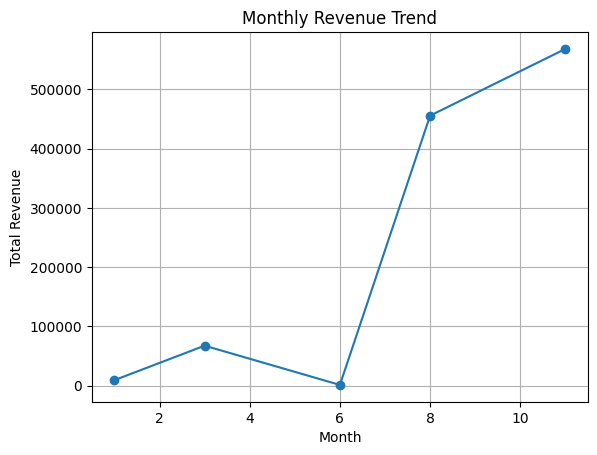

In [58]:
monthly = df.groupby("Month")["Total_Revenue"].sum()
monthly.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

# Data Visualization & Insights (Power BI Style with Pandas/Matplotlib)

<Axes: title={'center': 'Total Profit by Item Type'}, xlabel='Item_Type'>

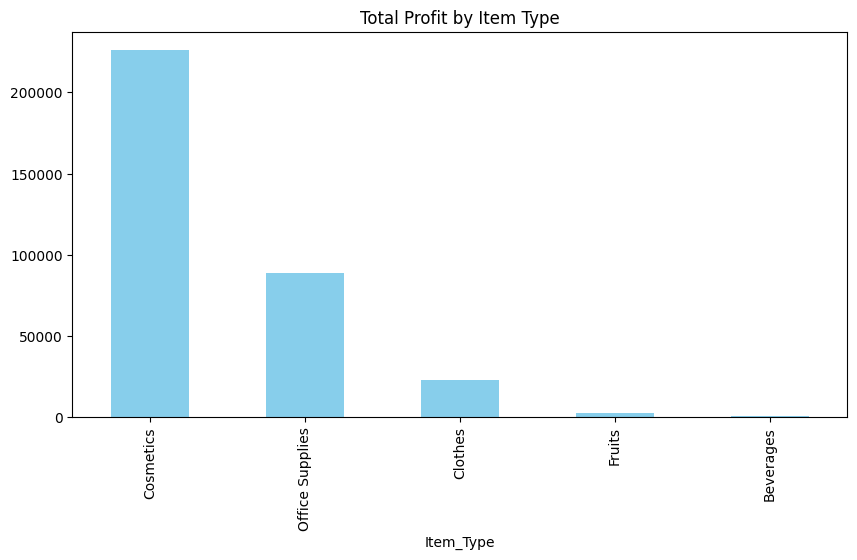

In [59]:
# Item Type vs. Total Profit (Bar Chart):

item_profit = df.groupby("Item_Type")["Total_Profit"].sum().sort_values(ascending=False)
item_profit.plot(kind="bar", figsize=(10,5), color="skyblue", title="Total Profit by Item Type")

<Axes: title={'center': 'Revenue Share by Region'}, ylabel='Total_Revenue'>

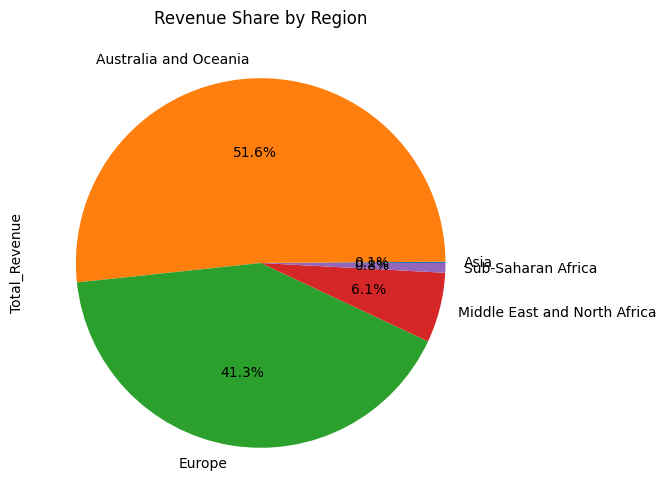

In [65]:
#  Region vs. Total Revenue (Pie Chart):

region_revenue = df.groupby("Region")["Total_Revenue"].sum()
region_revenue.plot(kind="pie", autopct='%2.1f%%', figsize=(16,6), title="Revenue Share by Region")

<Axes: title={'center': 'Orders by Priority'}, ylabel='Order_Priority'>

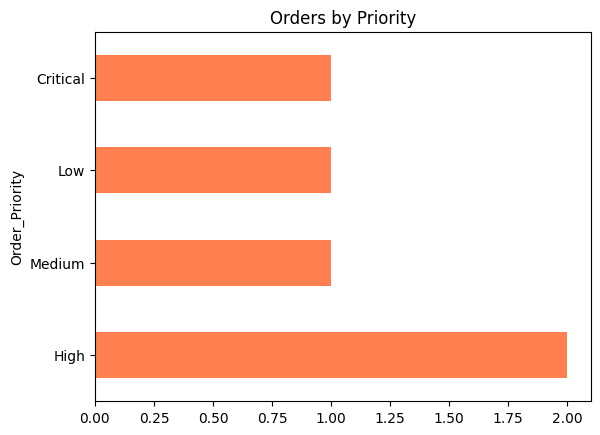

In [66]:
 # Order Priority count (Horizontal bar):

df["Order_Priority"].value_counts().plot(kind="barh", color="coral", title="Orders by Priority")

<Axes: title={'center': 'Monthly Orders'}, xlabel='Month'>

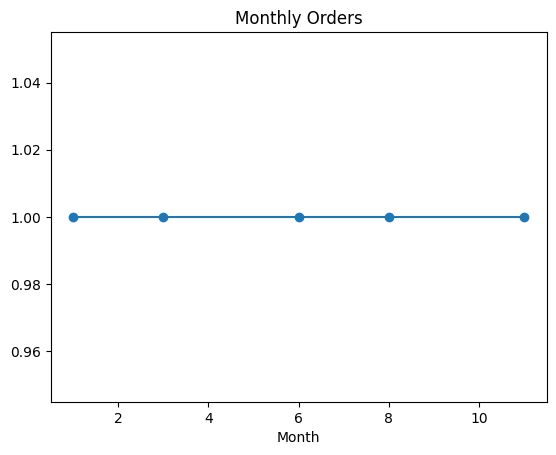

In [69]:
# Monthly Sales Count (Line Plot):

monthly_sales = df.groupby("Month")["Order_ID"].count()
monthly_sales.plot(kind="line", marker='o', title="Monthly Orders")

In [72]:
# Top 5 Selling Item Types (based on Revenue):

df.groupby("Item_Type")["Total_Revenue"].sum().sort_values(ascending=False).head(5)

Item_Type
Cosmetics          568360
Office Supplies    455700
Clothes             67500
Fruits               9330
Beverages            1250
Name: Total_Revenue, dtype: int64

In [90]:
# Create a function to visualize any column with bar plot:

def plot_bar(column):
    df[column].value_counts().plot(kind="bar", color = "darkgreen",title=f"{column} Distribution")

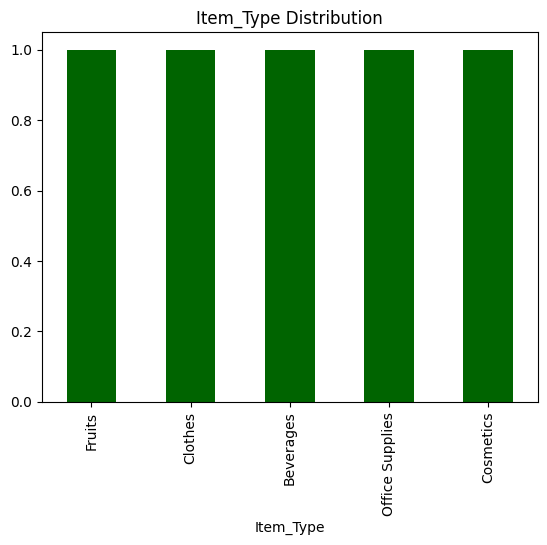

In [91]:
plot_bar("Item_Type")

In [74]:
df

,Region,Country,Item_Type,Sales_Channel,Order_Priority,Order_Date,Order_ID,Units_Sold,Unit_Price,Unit_Cost,Total_Revenue,Total_Cost,Total_Profit,Profit_Percent,Year,Month
0,Sub-Saharan Africa,South Africa,Fruits,Offline,High,2020-01-01,123456789,1000,9.33,6.92,9330,6920,2410,25.830654,2020,1
1,Middle East and North Africa,Egypt,Clothes,Online,Medium,2020-03-15,234567890,1500,45.00,30.00,67500,45000,22500,33.333333,2020,3
2,Asia,India,Beverages,Online,Low,2020-06-10,345678901,500,2.50,1.50,1250,750,500,40.000000,2020,6
3,Europe,Germany,Office Supplies,Offline,Critical,2020-08-05,456789012,700,651.00,524.00,455700,366800,88900,19.508449,2020,8
4,Australia and Oceania,Australia,Cosmetics,Online,High,2020-11-20,567890123,1300,437.20,263.30,568360,342290,226070,39.775846,2020,11


#  Pivot Tables + Advanced Aggregation (Real Job Style)

In [94]:
#  Region vs Order Priority vs Total Revenue (Pivot Table style):

df.pivot_table(values="Total_Revenue", index="Region", columns="Order_Priority", aggfunc="sum", fill_value=0)

Order_Priority,Critical,High,Low,Medium
Region,,,,
Asia,0,0,1250,0
Australia and Oceania,0,568360,0,0
Europe,455700,0,0,0
Middle East and North Africa,0,0,0,67500
Sub-Saharan Africa,0,9330,0,0


In [98]:
# Item Type vs Mean Profit, Total Revenue:

df.groupby("Item_Type")[["Total_Profit", "Total_Revenue"]].agg(["mean", "sum"]).round(1)

Total_Profit         Total_Revenue        
                        mean     sum          mean     sum
Item_Type                                                 
Beverages              500.0     500        1250.0    1250
Clothes              22500.0   22500       67500.0   67500
Cosmetics           226070.0  226070      568360.0  568360
Fruits                2410.0    2410        9330.0    9330
Office Supplies      88900.0   88900      455700.0  455700

In [99]:
# Top 3 Regions by Total Profit:

df.groupby("Region")["Total_Profit"].sum().sort_values(ascending=False).head(3)

Region
Australia and Oceania           226070
Europe                           88900
Middle East and North Africa     22500
Name: Total_Profit, dtype: int64

In [100]:
# Orders per Month by Region (like Pivot Table):

df.pivot_table(values="Order_ID", index="Month", columns="Region", aggfunc="count", fill_value=0)

Region,Asia,Australia and Oceania,Europe,Middle East and North Africa,Sub-Saharan Africa
Month,,,,,
1,0,0,0,0,1
3,0,0,0,1,0
6,1,0,0,0,0
8,0,0,1,0,0
11,0,1,0,0,0


In [101]:
# GroupBy Multiple Columns + Aggregation:

df.groupby(["Region", "Order_Priority"]).agg({
    "Order_ID": "count",
    "Total_Revenue": "sum",
    "Total_Profit": "mean"
})


,,Order_ID,Total_Revenue,Total_Profit
Region,Order_Priority,,,
Asia,Low,1,1250,500.0
Australia and Oceania,High,1,568360,226070.0
Europe,Critical,1,455700,88900.0
Middle East and North Africa,Medium,1,67500,22500.0
Sub-Saharan Africa,High,1,9330,2410.0


In [102]:
# Which Item_Type has Highest Avg Profit per Order?

df.groupby("Item_Type")["Total_Profit"].mean().sort_values(ascending=False).head(1)


Item_Type
Cosmetics    226070.0
Name: Total_Profit, dtype: float64

# Mini Project (Sales Report Generation)

In [103]:
print("Total Revenue:", df["Total_Revenue"].sum())

Total Revenue: 1102140


In [104]:
print("Total Orders:", df["Order_ID"].nunique())

Total Orders: 5


In [105]:
print("Average Profit per Order:", df["Total_Profit"].mean())

Average Profit per Order: 68076.0


<Axes: title={'center': 'Top 5 Item Types by Total Profit'}, xlabel='Item_Type'>

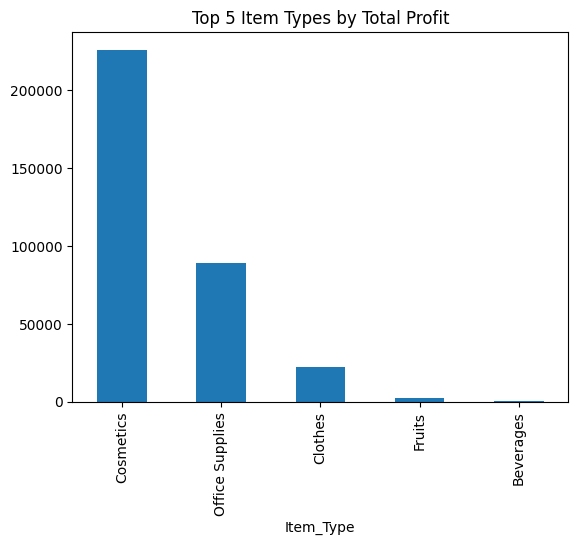

In [106]:
# Top 5 Performing Item Types by Total Profit (Bar Chart):

top_items = df.groupby("Item_Type")["Total_Profit"].sum().sort_values(ascending=False).head(5)
top_items.plot(kind="bar", title="Top 5 Item Types by Total Profit")

<Axes: title={'center': 'Revenue by Region'}, ylabel='Total_Revenue'>

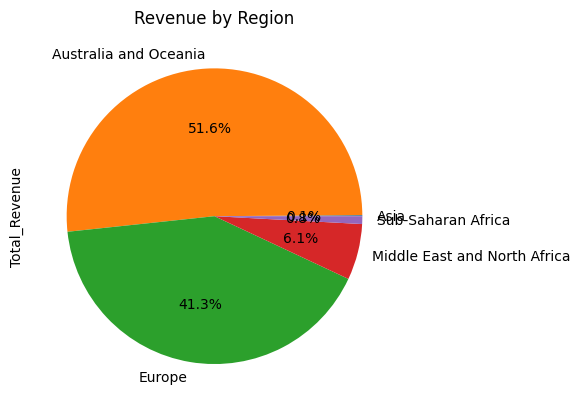

In [107]:
# Region-wise Revenue Distribution (Pie Chart):

df.groupby("Region")["Total_Revenue"].sum().plot(kind="pie", autopct='%1.1f%%', title="Revenue by Region")

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month'>

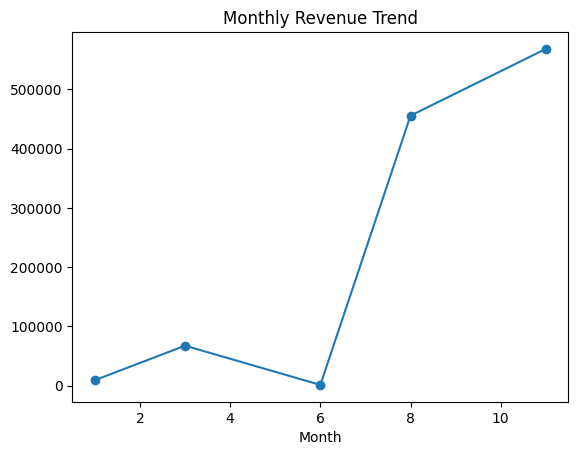

In [108]:
# Monthly Sales Trend (Line Chart):

df.groupby("Month")["Total_Revenue"].sum().plot(kind="line", marker='o', title="Monthly Revenue Trend")

In [109]:
# Pivot Table: Region vs Order Priority → Total Orders:

pd.pivot_table(df, values="Order_ID", index="Region", columns="Order_Priority", aggfunc="count", fill_value=0)

Order_Priority,Critical,High,Low,Medium
Region,,,,
Asia,0,0,1,0
Australia and Oceania,0,1,0,0
Europe,1,0,0,0
Middle East and North Africa,0,0,0,1
Sub-Saharan Africa,0,1,0,0


In [110]:
#  Save output charts to PNG and Export final summary as CSV or Excel:

df.to_excel("Sales_Report_Final.xlsx", index=False)